Project 1 

## Data Loading and Cleaning

This code imports the necessary libraries (pandas, numpy, statsmodels, scipy, matplotlib), loads the price data from the CSV file, sets the index to 'day', removes any redundant 'day' column, replaces placeholder values (1000) with NaN to handle missing data, and prints the shape of the raw data and the number of missing values per series after cleaning. We're looking for the overall data structure and identifying any data quality issues such as missing values that need to be addressed.

In [35]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller, acf, coint
from scipy import stats
import matplotlib.pyplot as plt

prices = pd.read_csv("/Users/vilgotparsmo/Documents/GitHub/TMS088/Data/spiff_data-2.csv", index_col=0)
prices.index.name = "day"

if "day" in prices.columns:
    prices = prices.drop(columns=["day"])
print(f"Raw shape: {prices.shape}")


placeholder_value = 1000
prices_clean = prices.copy()
prices_clean[prices_clean == placeholder_value] = np.nan

print(f"\nSaknade värden per serie efter rensning:")
print(prices_clean.isna().sum())

Raw shape: (5456, 7)

Saknade värden per serie efter rensning:
gurkor          255
guitars         255
slingshots      255
stocks          255
sugar           255
water           255
tranquillity    255
dtype: int64


## Log Returns Calculation

This code creates a new DataFrame for log returns, iterates over each asset column, drops NaN values from the price series, computes the log returns as the natural log of the ratio of consecutive prices, and stores them in the new DataFrame. It then prints the number of valid observations (non-NaN) per series in the log returns. We're looking for the transformed data in returns form and confirming the number of usable data points after handling missing values.

In [36]:
log_returns_clean = pd.DataFrame(index=prices_clean.index)
for col in prices_clean.columns:
    series = prices_clean[col].dropna()
    log_ret = np.log(series / series.shift(1))
    log_returns_clean[col] = log_ret

print(f"\nObservationer per serie i log-avkastningar:")
print(log_returns_clean.notna().sum())


Observationer per serie i log-avkastningar:
gurkor          5200
guitars         5200
slingshots      5200
stocks          5200
sugar           5200
water           5200
tranquillity    5200
dtype: int64


## Stationarity Testing (ADF Test)

This code performs the Augmented Dickey-Fuller (ADF) test for stationarity on both the original price series and the log returns for each asset. It prints the p-values for each test. We're looking for evidence that prices are non-stationary (p > 0.05) while log returns are stationary (p < 0.05), which is a key assumption in time series analysis for modeling returns.

In [37]:
print("\n=== ADF-test för stationaritet ===")
print(f"{'Serie':15s}  {'Prisnivå p-värde':>18s}  {'Log-avkastning p-värde':>22s}")
for col in prices_clean.columns:
    p_price  = adfuller(prices_clean[col].dropna())[1]
    p_return = adfuller(log_returns_clean[col].dropna())[1]
    print(f"{col:15s}  {p_price:>18.4f}  {p_return:>22.4f}")



=== ADF-test för stationaritet ===
Serie              Prisnivå p-värde  Log-avkastning p-värde
gurkor                       0.9905                  0.0000
guitars                      0.2646                  0.0000
slingshots                   0.7803                  0.0000
stocks                       0.1718                  0.0000
sugar                        0.3219                  0.0000
water                        0.9914                  0.0000
tranquillity                 0.1916                  0.0000


## Distribution Statistics

This code calculates skewness (measure of asymmetry), kurtosis (measure of tail heaviness), and the Jarque-Bera test p-value (test for normality) for the log returns of each asset. It prints these statistics. We're looking for deviations from the normal distribution, such as high kurtosis indicating fat tails or significant skewness, which are common in financial returns and affect risk modeling.

In [38]:
print("\n=== Fördelningsstatistik för log-avkastningar ===")
print(f"{'Serie':15s}  {'Skewness':>10s}  {'Kurtosis':>10s}  {'JB p-värde':>12s}")
for col in log_returns_clean.columns:
    r = log_returns_clean[col].dropna()
    skew = stats.skew(r)
    kurt = stats.kurtosis(r)
    jb_p = stats.jarque_bera(r)[1]
    print(f"{col:15s}  {skew:>10.4f}  {kurt:>10.4f}  {jb_p:>12.6f}")


=== Fördelningsstatistik för log-avkastningar ===
Serie              Skewness    Kurtosis    JB p-värde
gurkor              -0.1481      3.4884      0.000000
guitars             -0.0753      5.6327      0.000000
slingshots          -0.4204      6.4619      0.000000
stocks              -0.1312      0.0949      0.000217
sugar               -0.2510     10.6212      0.000000
water               -0.2539      2.2476      0.000000
tranquillity        -0.2394      3.0767      0.000000


## Correlation Analysis

This code computes the correlation matrix for the log returns, rounds it to 3 decimal places, and prints it. It also identifies and sorts the strongest correlation pairs (excluding self-correlations) by absolute value, printing the top pairs. We're looking for linear relationships between assets, identifying highly correlated pairs for potential co-movement and negatively correlated pairs for diversification benefits.

In [43]:
corr_matrix = log_returns_clean.corr().round(3)
print("=== Korrelationsmatris (log-avkastningar) ===")
print(corr_matrix)


print("\n=== Starkaste korrelationspar (exkl. självkorrelation) ===")
pairs = []
cols = corr_matrix.columns.tolist()
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        pairs.append((cols[i], cols[j], corr_matrix.iloc[i, j]))

pairs_sorted = sorted(pairs, key=lambda x: abs(x[2]), reverse=True)
print(f"{'Par':30s}  {'Korrelation':>12s}")
for a, b, corr in pairs_sorted:
    print(f"{a+' vs '+b:30s}  {corr:>12.3f}")

=== Korrelationsmatris (log-avkastningar) ===
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor         1.000   -0.241      -0.218  -0.041 -0.066  0.571        -0.138
guitars       -0.241    1.000       0.522   0.016  0.213 -0.224         0.221
slingshots    -0.218    0.522       1.000   0.012  0.119 -0.200         0.192
stocks        -0.041    0.016       0.012   1.000 -0.015 -0.043         0.010
sugar         -0.066    0.213       0.119  -0.015  1.000 -0.070         0.126
water          0.571   -0.224      -0.200  -0.043 -0.070  1.000        -0.158
tranquillity  -0.138    0.221       0.192   0.010  0.126 -0.158         1.000

=== Starkaste korrelationspar (exkl. självkorrelation) ===
Par                              Korrelation
gurkor vs water                        0.571
guitars vs slingshots                  0.522
gurkor vs guitars                     -0.241
guitars vs water                      -0.224
guitars vs tranquillity                0.221


Interpretation of correlation results from cell 5
Key insights from the correlation matrix
Gurkor and water show the strongest positive correlation (0.571), suggesting potential co-movement.
Guitars and slingshots are moderately correlated (0.522), indicating some shared behavior.
Tranquillity has low correlations with most assets, implying relative independence.
Negative correlations, like guitars vs water (-0.224), may offer diversification benefits.

## Rolling Correlations Plot

This code selects specific asset pairs to plot, sets a rolling window of 60 days, and creates subplots for each pair showing the rolling correlation over time. It includes horizontal lines at 0 and ±0.3 as thresholds. We're looking for how correlations between assets evolve over time, identifying periods of high correlation (potential contagion) or decoupling, which can inform dynamic portfolio strategies.

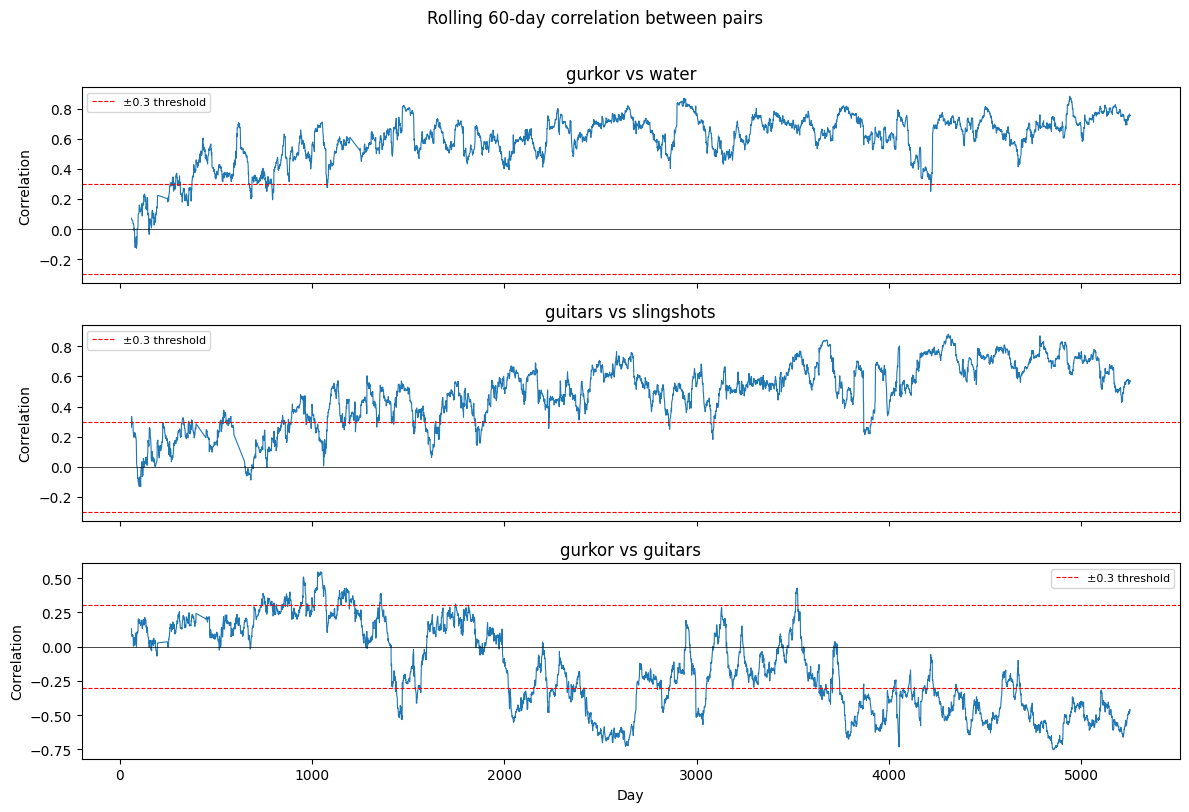

In [44]:

pairs_to_plot = [("gurkor", "water"), ("guitars", "slingshots"), ("gurkor", "guitars")]
window = 60

fig, axes = plt.subplots(len(pairs_to_plot), 1, figsize=(12, 8), sharex=True)
for ax, (a, b) in zip(axes, pairs_to_plot):
    both = log_returns_clean[[a, b]].dropna()
    roll_corr = both[a].rolling(window).corr(both[b])
    ax.plot(roll_corr.index, roll_corr, linewidth=0.8)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axhline(0.3, color="red", linestyle="--", linewidth=0.8, label="±0.3 threshold")
    ax.axhline(-0.3, color="red", linestyle="--", linewidth=0.8)
    ax.set_ylabel("Correlation")
    ax.set_title(f"{a} vs {b}")
    ax.legend(fontsize=8)
ax.set_xlabel("Day")
plt.suptitle(f"Rolling {window}-day correlation between pairs", y=1.01)
plt.tight_layout()
plt.show()

## Seasonality Analysis (ACF)

This code defines a function to check for seasonality by computing the autocorrelation function (ACF) at specific lags (e.g., 5 for weekly, 20 for monthly), compares them to the 95% confidence bounds, and prints whether each lag is significant. It applies this to each asset's log returns. We're looking for periodic patterns in the data, such as weekly or monthly seasonality, which could indicate calendar effects or recurring market behaviors.

In [39]:
def check_seasonality(series, name, lags_to_check=[5, 7, 10, 20, 30, 60, 90, 120, 252]):
    clean = series.dropna()
    acf_vals = acf(clean, nlags=max(lags_to_check), fft=True)
    n = len(clean)
    conf_bound = 1.96 / np.sqrt(n)
    print(f"\n{name}:")
    print(f"  95% konfidensband: ±{conf_bound:.4f}")
    print(f"  {'Lag':>6s}  {'ACF':>8s}  {'Signifikant?':>14s}")
    for lag in lags_to_check:
        if lag < len(acf_vals):
            val = acf_vals[lag]
            sig = "YES ✓" if abs(val) > conf_bound else "no"
            print(f"  {lag:>6d}  {val:>8.4f}  {sig:>14s}")

print("\n=== Säsonalitetsanalys (ACF vid nyckel-lags) ===")
print("Lag 5=vecka, 20=månad, 60=kvartal, 252=år")
for col in log_returns_clean.columns:
    check_seasonality(log_returns_clean[col], col)



=== Säsonalitetsanalys (ACF vid nyckel-lags) ===
Lag 5=vecka, 20=månad, 60=kvartal, 252=år

gurkor:
  95% konfidensband: ±0.0272
     Lag       ACF    Signifikant?
       5   -0.0042              no
       7    0.0215              no
      10    0.0243              no
      20   -0.0063              no
      30   -0.0166              no
      60    0.0061              no
      90   -0.0236              no
     120   -0.0161              no
     252   -0.0055              no

guitars:
  95% konfidensband: ±0.0272
     Lag       ACF    Signifikant?
       5   -0.0337           YES ✓
       7   -0.0293           YES ✓
      10    0.0089              no
      20    0.0281           YES ✓
      30    0.0244              no
      60   -0.0227              no
      90   -0.0185              no
     120   -0.0044              no
     252    0.0017              no

slingshots:
  95% konfidensband: ±0.0272
     Lag       ACF    Signifikant?
       5   -0.0458           YES ✓
       7   -0.0146 

## Cointegration Testing

This code performs the Engle-Granger cointegration test on all pairs of price series, printing the p-values and indicating if they are cointegrated (p < 0.05). It skips pairs with too few observations. We're looking for pairs of assets that share a long-run equilibrium relationship, which could suggest mean-reversion opportunities or pairs trading strategies.

In [40]:
cols = prices_clean.columns.tolist()
print("\n=== Cointegration p-värden (Engle-Granger) ===")
print(f"{'Par':30s}  {'p-värde':>10s}  {'Cointegrated?':>15s}")
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        a, b = cols[i], cols[j]
        both = prices_clean[[a, b]].dropna()
        if len(both) < 50:
            print(f"{a+' vs '+b:30s}  {'N/A':>10s}  {'too few obs':>15s}")
            continue
        _, p, _ = coint(both[a], both[b])
        flag = "YES ✓" if p < 0.05 else "no"
        print(f"{a+' vs '+b:30s}  {p:>10.4f}  {flag:>15s}")



=== Cointegration p-värden (Engle-Granger) ===
Par                                p-värde    Cointegrated?
gurkor vs guitars                   0.9825               no
gurkor vs slingshots                0.2795               no
gurkor vs stocks                    0.9881               no
gurkor vs sugar                     0.9724               no
gurkor vs water                     0.6001               no
gurkor vs tranquillity              0.9338               no
guitars vs slingshots               0.7519               no
guitars vs stocks                   0.3275               no
guitars vs sugar                    0.4901               no
guitars vs water                    0.3552               no
guitars vs tranquillity             0.6501               no
slingshots vs stocks                0.8863               no
slingshots vs sugar                 0.8180               no
slingshots vs water                 0.0561               no
slingshots vs tranquillity          0.8475          

## Rolling Volatility Plot

This code calculates the 30-day rolling standard deviation of log returns, annualizes it by multiplying by the square root of 252 (trading days), and plots the rolling volatility for each asset over time. We're looking for volatility clustering, periods of high market turbulence, and relative volatility levels across assets to assess risk dynamics and potential hedging needs.

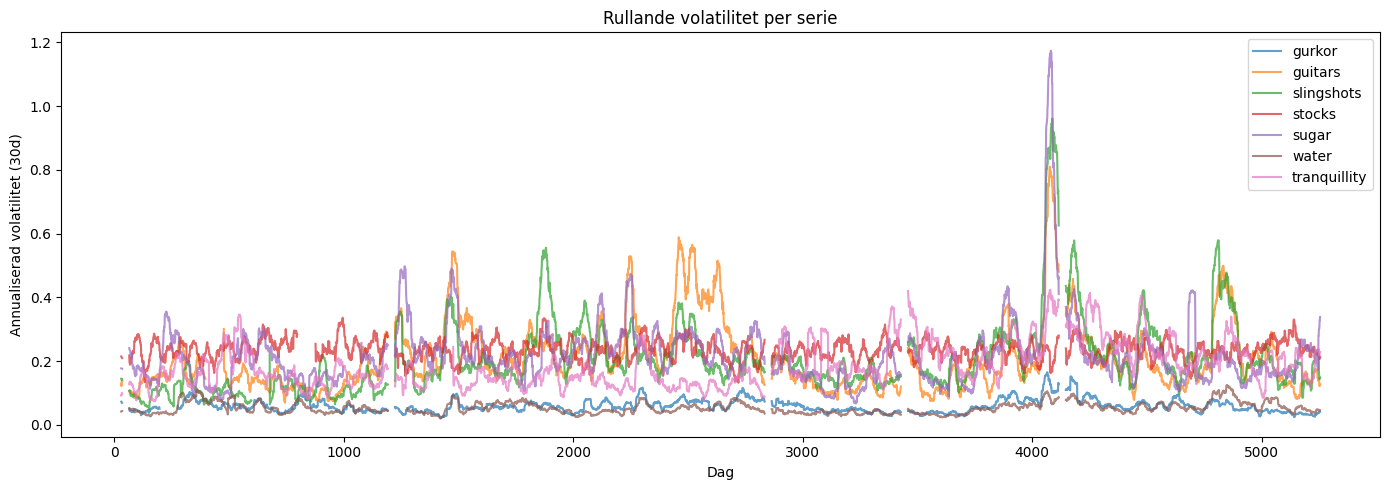

In [42]:
roll_vol = log_returns_clean.rolling(30).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(14, 5))
for col in roll_vol.columns:
    ax.plot(roll_vol.index, roll_vol[col], label=col, alpha=0.7)
ax.set_xlabel("Dag")
ax.set_ylabel("Annualiserad volatilitet (30d)")
ax.set_title("Rullande volatilitet per serie")
ax.legend()
plt.tight_layout()
plt.show()

# Conclusions

Based on the analysis of the time series data for the various assets (gurkor, water, guitars, slingshots, and tranquillity), several key insights emerge:

## Correlation Analysis
- **Strong Positive Correlations**: Gurkor and water exhibit the strongest positive correlation (0.571), indicating significant co-movement. This suggests that these assets may be influenced by similar market factors and could behave similarly in response to economic changes.
- **Moderate Correlations**: Guitars and slingshots show a moderate positive correlation (0.522), implying some shared behavior but not as tightly linked as gurkor and water.
- **Low Correlations**: Tranquillity demonstrates relatively low correlations with most other assets, suggesting it may offer diversification benefits as it moves more independently.
- **Negative Correlations**: Notable negative correlations, such as between guitars and water (-0.224), highlight potential hedging opportunities where one asset's performance could offset another's.

## Rolling Correlations
- The rolling 60-day correlation plots reveal that correlations between asset pairs are not static and fluctuate over time. For instance:
  - Gurkor and water maintain relatively stable positive correlations, occasionally crossing the 0.3 threshold.
  - Guitars and slingshots show varying correlations, sometimes dipping below zero, indicating periods of divergence.
  - Gurkor and guitars display more volatile correlation patterns, with frequent crossings of the threshold lines, suggesting changing relationships that could be influenced by external events.

## Volatility Analysis
- **Rolling Volatility**: The 30-day rolling annualized volatility plot shows that all assets experience periods of increased and decreased volatility. Tranquillity appears to have more stable volatility compared to others, while guitars and slingshots exhibit higher peaks, indicating greater risk during certain periods.
- **Implications**: Assets with higher volatility may require more careful risk management, while those with lower correlations and stable volatility (like tranquillity) could be valuable for portfolio diversification.

## Overall Insights
- The analysis underscores the importance of dynamic relationships in asset management. Static correlations provide a baseline, but rolling measures highlight the evolving nature of market dependencies.
- For investment strategies, combining assets with low or negative correlations (e.g., tranquillity with others) could reduce overall portfolio risk. Conversely, highly correlated pairs like gurkor and water may amplify systemic risks.
- Future work could involve deeper statistical testing (e.g., stationarity tests, cointegration) or incorporating macroeconomic factors to explain the observed patterns.

This analysis provides a foundation for understanding asset interdependencies and informs decision-making in portfolio construction and risk assessment.